# Volatility forecasting: models, backtests and the feature question

This notebook records how the dashboard's volatility forecast was chosen.
It re-runs every backtest behind that choice:

1. **The target** and the data.
2. **The method**: walk-forward backtesting with no look-ahead.
3. **The models**: implied vol, GARCH, GJR-GARCH, HAR and its variants,
   gradient boosting, LSTM and LSTM-GARCH.
4. **Backtest results** at 5- and 21-trading-day horizons, with
   significance tests and a breakdown by volatility regime.
5. **Are the surface features useful?** Feature-group ablations, plus tests
   on returns and on variance-swap P&L.
6. **The production model**: pooling across tickers, interval calibration,
   and its live 2026 track record.

All code comes from `src/forecast/` (LSTMs from `experimental/forecast/`).
A full run takes about 20 minutes, mostly the LSTMs.

In [1]:
import os, sys, math, time, warnings
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._build.plotting import THEME as T, style_axes, setup_matplotlib
setup_matplotlib()
pd.set_option("display.width", 160, "display.max_columns", 20, "display.precision", 4)

from src.forecast.dataset import build_dataset
from src.forecast.evaluate import (compare, by_regime, walk_forward, scores, qlike_series,
                                   diebold_mariano, predictive_regression)
from src.forecast import models as M

START, END = "2013-01-01", "2025-12-31"   # out-of-sample span; 2010-2012 is warm-up

## 1. The target and the data

The target is **realised variance over the next h trading days**,
annualised: `y_h(t) = 252/h · Σ_{i=1..h} r²_{t+i}`, from close-to-close log
returns. That is exactly what a variance swap pays, so implied variance is
scored on what it actually prices. Every forecast made at the close of day
*t* uses only information available then.

Each row joins the inputs the models can see:
- HAR inputs: daily, weekly and monthly averages of a daily variance estimate
  (below);
- the surface and VIX-family features from the feature tables. SPY has them
  for 2010–2025 (historical) and 2026 (live).

4,465 trading days, 2009-01-05 to 2026-10-05
surface-feature coverage by year: {2009: 0.0, 2010: 0.96, 2011: 0.97, 2012: 0.99, 2013: 1.0, 2014: 0.99, 2015: 1.0, 2016: 1.0, 2017: 1.0, 2018: 1.0, 2019: 0.98, 2020: 0.99, 2021: 1.0, 2022: 0.98, 2023: 1.0, 2024: 1.0, 2025: 0.94, 2026: 0.82}


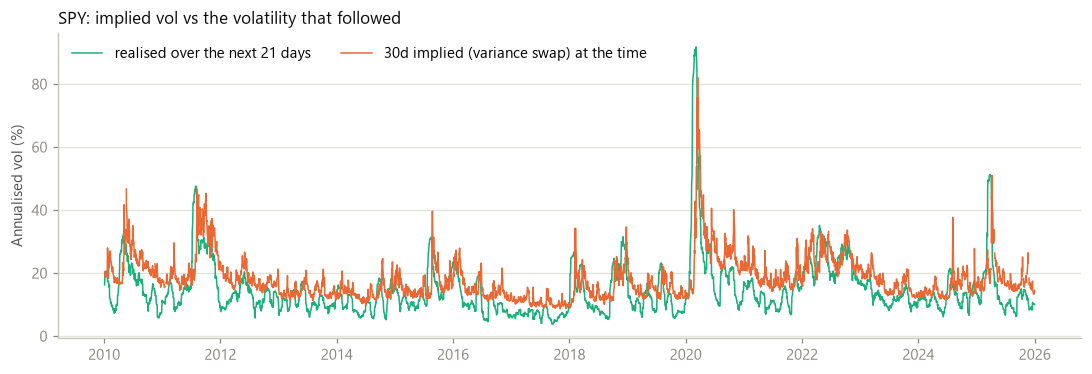

Implied exceeded subsequent realised vol on 84% of days; mean gap 3.5 vol pts (the volatility risk premium)


In [2]:
ds = build_dataset("SPY")
print(f"{len(ds):,} trading days, {ds.index.min().date()} to {ds.index.max().date()}")
print("surface-feature coverage by year:",
      ds["vs_30d"].notna().groupby(ds.index.year).mean().round(2).to_dict())

fig, ax = plt.subplots(figsize=(12, 3.6))
s = ds.loc["2010":"2025"]
ax.plot(s.index, 100 * np.sqrt(s["y_21"]), color=T.series[2], lw=1, label="realised over the next 21 days")
ax.plot(s.index, 100 * s["vs_30d"], color=T.series[1], lw=1, label="30d implied (variance swap) at the time")
style_axes(ax, "SPY: implied vol vs the volatility that followed", None, "Annualised vol (%)")
ax.legend(frameon=False, ncol=2); plt.show()
vrp = (s["vs_30d"] - np.sqrt(s["y_21"])).dropna()
print(f"Implied exceeded subsequent realised vol on {100 * (vrp > 0).mean():.0f}% of days; "
      f"mean gap {100 * vrp.mean():.1f} vol pts (the volatility risk premium)")

### A better daily variance estimate for the HAR inputs

Without intraday data, a squared daily return is a very noisy estimate of
that day's variance. The Garman-Klass estimator uses open, high, low and
close, plus the overnight gap, all dividend-adjusted. It is several times
more precise and matches close-to-close variance on average:

In [3]:
c2c = 252 * ds["ret"] ** 2
cmp = pd.DataFrame({"mean": [c2c.mean(), ds["rv_d"].mean()],
                    "sd of log (noise)": [np.log(c2c[c2c > 0]).std(), np.log(ds["rv_d"][ds["rv_d"] > 0]).std()]},
                   index=["close-to-close r²", "Garman-Klass + overnight"])
cmp.round(4)

,mean,sd of log (noise)
close-to-close r²,0.0315,2.5007
Garman-Klass + overnight,0.0327,1.2199


## 2. The method: walk-forward, with no look-ahead

Forecasts for 2013–2025 are made walk-forward. Every 21 trading days each
model is refitted on the data available at that point, then forecasts the
next block.

The subtle part: a row's 21-day target overlaps the following 20 days. At a
refit on day *t₀*, a model may train only on rows whose target window had
closed (row *r* with `r + h ≤ t₀`). Training on the latest rows would leak up
to 20 days of the future into every fit, which is a common flaw in published
volatility-forecasting results. `walk_forward` enforces this, and a unit
test checks it.

**Scoring.**
- **QLIKE**, `y/f − log(y/f) − 1`: the loss that ranks variance forecasts
  correctly when realised variance is a noisy proxy (Patton, 2011). It
  penalises under-forecasting more than over-forecasting.
- RMSE and bias in vol points, and R² of log variance.
- **Diebold-Mariano tests** on QLIKE, with Newey-West standard errors over h
  lags because the targets overlap.

## 3. The models

| Model | Inputs | Idea |
|---|---|---|
| Implied (raw) | implied vol (VIX9D for 5 days, our 30d variance swap for 21 days) | the market's own forecast, including its risk premium |
| Implied (recalibrated) | the same | log-regression of realised on implied, removing the premium |
| GARCH(1,1), GJR-GARCH | daily returns | the textbook econometric models (Student-t errors) |
| HAR | daily/weekly/monthly realised variance | Corsi (2009), the standard realised-vol benchmark, in logs |
| HAR + implied | HAR + log implied variance | |
| HAR + surface | + 91d variance swap, term spreads, skew, butterfly, VIX3M/VIX, VVIX, CBOE SKEW, VRP | ridge-regularised |
| Gradient boosting | the same inputs as HAR + surface | non-linear |
| LSTM / LSTM-GARCH | 22-day sequences of HAR inputs, returns and implied (+ GJR-GARCH's own forecast) | the deep-learning challengers |

Log-linear forecasts are de-biased with Duan's smearing estimator. On the
full sample, the fitted HAR + implied model looks like this:

In [4]:
full = ds.loc[:END]
for h in (5, 21):
    m = M.har_iv().fit(full.dropna(subset=[f"y_{h}"]), h)
    print(f"h={h}: standardised coefficients", m.coefficients().round(3).to_dict())

h=5: standardised coefficients {'log_rv_d': 0.046, 'log_rv_w': 0.104, 'log_rv_m': -0.059, 'log_iv': 0.824}
h=21: standardised coefficients {'log_rv_d': 0.065, 'log_rv_w': 0.094, 'log_rv_m': -0.002, 'log_iv': 0.503}


Once implied vol is in the model, the historical-variance terms shrink
towards zero: implied vol already contains most of what past volatility says.

## 4. Backtest results

In [5]:
results = {}
for h in (5, 21):
    t0 = time.time()
    fc, rep = compare(ds, M.standard_models(), h, start=START, end=END)
    results[h] = (fc, rep)
    print(f"h={h}: {len(fc.dropna())} common out-of-sample days ({time.time() - t0:.0f}s)")
    display(rep.sort_values("qlike")[["qlike", "rmse_vol", "bias_vol", "r2_log", "dm_stat", "dm_p"]].round(4))

h=5: 3143 common out-of-sample days (168s)


,qlike,rmse_vol,bias_vol,r2_log,dm_stat,dm_p
model,,,,,,
HAR + surface,0.3739,6.9765,1.2305,0.4680,5.1025,0.0000
Implied (recalibrated),0.3744,7.1090,1.1912,0.4691,4.0767,0.0000
HAR + implied,0.3749,7.0699,1.1480,0.4717,4.2642,0.0000
Implied (raw),0.4242,7.5966,3.6143,0.1772,0.6219,0.5340
HAR,0.4345,7.4429,1.3382,0.3405,NaN,NaN
GJR-GARCH,0.4711,7.6828,1.9958,0.2870,-1.7238,0.0848
GARCH,0.4733,7.9657,2.1480,0.2199,-3.4364,0.0006
Gradient boosting,0.4909,7.9616,-0.0757,0.4332,-2.0409,0.0413


h=21: 3143 common out-of-sample days (158s)


,qlike,rmse_vol,bias_vol,r2_log,dm_stat,dm_p
model,,,,,,
Implied (raw),0.3940,8.1171,3.0600,0.1140,0.1926,0.8473
HAR,0.3992,7.7330,1.0975,0.2726,NaN,NaN
HAR + implied,0.4045,7.5492,0.7981,0.3454,-0.2727,0.7851
Implied (recalibrated),0.4080,7.6413,0.8435,0.3388,-0.4373,0.6619
GARCH,0.4092,8.5100,2.2878,0.1399,-0.6183,0.5364
HAR + surface,0.4194,7.6402,1.2214,0.2813,-0.8600,0.3898
GJR-GARCH,0.4195,8.2624,1.7361,0.1861,-1.2477,0.2121
Gradient boosting,0.6019,8.2600,-0.4373,0.2608,-2.0973,0.0360


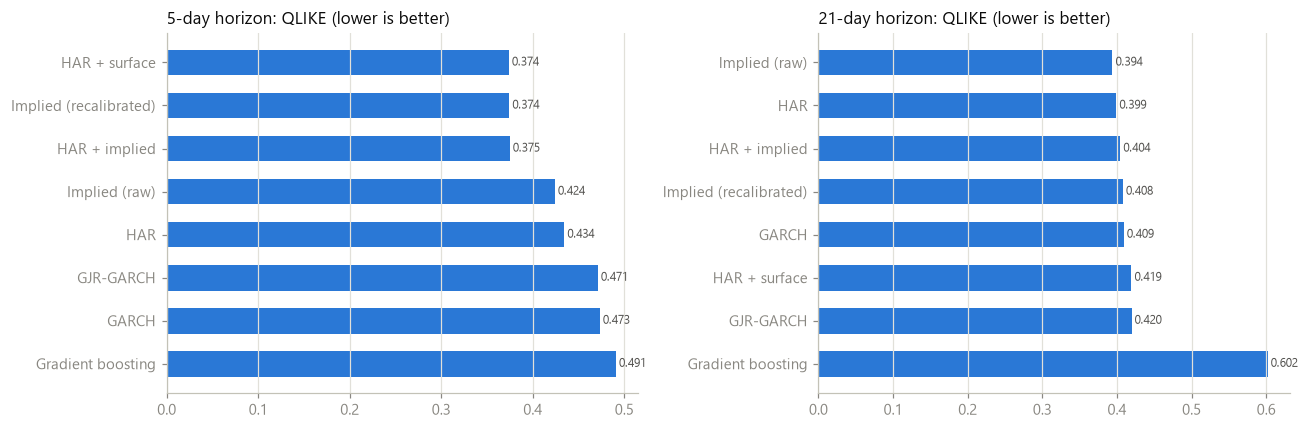

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h in zip(axes, (5, 21)):
    r = results[h][1]["qlike"].sort_values(ascending=False)
    ax.barh(r.index, r.values, color=T.series[0], height=0.6)
    for y, v in enumerate(r.values):
        ax.text(v, y, f" {v:.3f}", va="center", fontsize=8, color=T.ink_secondary)
    style_axes(ax, f"{h}-day horizon: QLIKE (lower is better)", None, None)
    ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.tight_layout(); plt.show()

`dm_stat` compares each model with HAR (positive means better). How to read
the tables:

- **5 days:** HAR + implied and recalibrated implied vol beat HAR
  decisively (p < 0.001). The market's short-dated implied vol carries real
  information about next week. Raw implied vol does not beat HAR
  significantly: its upward bias (the risk premium) costs about as much as
  its information gains.
- **21 days:** no model beats HAR significantly on QLIKE. Raw implied vol
  has the lowest QLIKE because QLIKE punishes under-forecasts and implied vol
  runs high, but it is biased by about 3 vol points. HAR + implied has the
  best RMSE and log-variance R².
- **GARCH** (returns only) is clearly worse than HAR, and **gradient
  boosting** overfits.

### By volatility regime

In [7]:
regime = pd.cut(ds["mkt_vix"], [0, 15, 25, 200], labels=["VIX<15", "VIX 15–25", "VIX>25"])
for h in (5, 21):
    print(f"h={h}: QLIKE by VIX level on the forecast date")
    display(by_regime(results[h][0], regime).T.round(3))

h=5: QLIKE by VIX level on the forecast date


,Implied (raw),Implied (recalibrated),GARCH,GJR-GARCH,HAR,HAR + implied,HAR + surface,Gradient boosting,n
VIX<15,0.508,0.446,0.531,0.501,0.482,0.444,0.436,0.563,1373.0
VIX 15–25,0.369,0.323,0.438,0.424,0.401,0.326,0.329,0.399,1409.0
VIX>25,0.322,0.303,0.394,0.543,0.385,0.301,0.312,0.575,361.0


h=21: QLIKE by VIX level on the forecast date


,Implied (raw),Implied (recalibrated),GARCH,GJR-GARCH,HAR,HAR + implied,HAR + surface,Gradient boosting,n
VIX<15,0.429,0.467,0.485,0.494,0.469,0.478,0.515,0.713,1373.0
VIX 15–25,0.367,0.352,0.356,0.362,0.341,0.345,0.354,0.496,1409.0
VIX>25,0.367,0.401,0.329,0.361,0.362,0.360,0.311,0.590,361.0


### The deep-learning challengers: LSTM and LSTM-GARCH

Both see the same inputs as HAR + implied, as 22-day sequences. LSTM-GARCH
also gets GJR-GARCH's forecast at each step, the usual hybrid design. They
use early stopping on a time-ordered validation split, and are refitted
quarterly to keep the run time reasonable. Refitting HAR + implied
quarterly instead of monthly changes its score by less than 0.001, so the
comparison is fair.

In [8]:
from experimental.forecast.lstm import lstm, lstm_garch

deep = {}
for h in (5, 21):
    t0 = time.time()
    fc = results[h][0][["y", "HAR + implied", "HAR"]].copy()
    fc["LSTM"] = walk_forward(ds, lstm, h, start=START, end=END, refit_every=63)
    fc["LSTM-GARCH"] = walk_forward(ds, lstm_garch, h, start=START, end=END, refit_every=63)
    deep[h] = fc
    common = fc.dropna()
    base = qlike_series(common["y"], common["HAR + implied"])
    rows = []
    for m in ["HAR + implied", "HAR", "LSTM", "LSTM-GARCH"]:
        s, p = (diebold_mariano(base, qlike_series(common["y"], common[m]), h)
                if m != "HAR + implied" else (np.nan, np.nan))
        rows.append({"model": m, **{k: v for k, v in scores(common["y"], common[m]).items() if k in ("qlike", "rmse_vol", "r2_log")},
                     "DM vs HAR+implied": s, "p": p})
    print(f"h={h}: {len(common)} common days ({time.time() - t0:.0f}s)")
    display(pd.DataFrame(rows).set_index("model").round(4))

h=5: 2767 common days (295s)


,qlike,rmse_vol,r2_log,DM vs HAR+implied,p
model,,,,,
HAR + implied,0.3761,7.0870,0.4860,NaN,NaN
HAR,0.4384,7.3534,0.3473,-4.0260,0.0001
LSTM,0.4153,7.6037,0.4044,-2.3428,0.0191
LSTM-GARCH,0.4334,7.8825,0.4168,-2.6320,0.0085


h=21: 2767 common days (282s)


,qlike,rmse_vol,r2_log,DM vs HAR+implied,p
model,,,,,
HAR + implied,0.4000,7.4120,0.3718,NaN,NaN
HAR,0.4023,7.6651,0.2761,-0.1113,0.9114
LSTM,0.4461,8.1743,0.2480,-1.3455,0.1785
LSTM-GARCH,0.4544,8.3192,0.2370,-1.2194,0.2227


Both deep models lose to HAR + implied, significantly at 5 days
(p ≈ 0.02 and 0.01) and insignificantly at 21. With about 2,700 overlapping
daily observations, a network has little signal to learn
from beyond what HAR's three averages and implied vol already capture. The
extra flexibility mostly fits noise.

### What the forecasts look like

Aligned the way the dashboard shows them: each forecast plotted on the day
its 21-day window closed, against what was realised over that window.

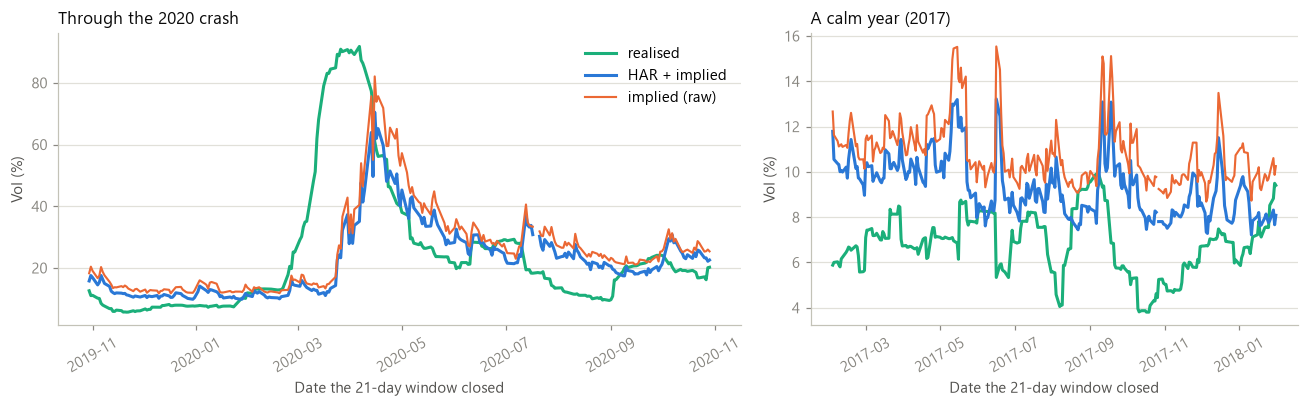

In [9]:
fc21 = results[21][0]
from src.dashboard.data import window_end
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.4, 1]})
for ax, (a, b, title) in zip(axes, [("2019-10-01", "2020-09-30", "Through the 2020 crash"),
                                    ("2017-01-01", "2017-12-31", "A calm year (2017)")]):
    z = fc21.loc[a:b].dropna(subset=["y"])
    x = window_end(z.index, 21).to_numpy()
    ax.plot(x, 100 * np.sqrt(z["y"]), color=T.series[2], lw=2, label="realised")
    ax.plot(x, 100 * np.sqrt(z["HAR + implied"]), color=T.series[0], lw=2, label="HAR + implied")
    ax.plot(x, 100 * np.sqrt(z["Implied (raw)"]), color=T.series[1], lw=1.4, label="implied (raw)")
    style_axes(ax, title, "Date the 21-day window closed", "Vol (%)")
    ax.tick_params(axis="x", rotation=30)
axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

No model saw the February 2020 jump coming; the market didn't either. After
it, HAR + implied tracks realised vol closely. In calm periods, raw implied
vol sits well above what is realised (the premium), and the model removes
most of that gap.

## 5. Are the surface features useful?

### For forecasting realised vol

Each feature group is added to HAR + implied on its own and tested against
it:

In [10]:
groups = {"skew (rr25, bf25, ATM skew)": ["rr25_30d", "bf25_30d", "atm_skew_30d"],
          "term structure (91d VS, 30→91 spread, VIX3M/VIX)": ["log_vs_91d", "ts_30_91", "log_vix_ts"],
          "vol-of-vol & tail (VVIX, CBOE SKEW)": ["log_vvix", "mkt_skew"],
          "variance risk premium": ["vrp_30d"]}
for h in (5, 21):
    facs = {"HAR + implied": M.har_iv}
    for g, cols in groups.items():
        facs[f"+ {g}"] = (lambda cols=cols, g=g: M.LogLinear(
            g, {**M.HAR_TERMS, **M.IV_TERMS, **{c: M.SURFACE_TERMS[c] for c in cols}}, alpha=5.0))
    _, abl = compare(ds, facs, h, start=START, end=END, baseline="HAR + implied")
    print(f"h={h}"); display(abl[["qlike", "r2_log", "dm_stat", "dm_p"]].round(4))

h=5


,qlike,r2_log,dm_stat,dm_p
model,,,,
HAR + implied,0.3749,0.4717,NaN,NaN
"+ skew (rr25, bf25, ATM skew)",0.3667,0.4768,0.9635,0.3353
"+ term structure (91d VS, 30→91 spread, VIX3M/VIX)",0.3715,0.4783,0.9452,0.3446
"+ vol-of-vol & tail (VVIX, CBOE SKEW)",0.3778,0.4795,-1.1196,0.2629
+ variance risk premium,0.3753,0.4703,-0.5757,0.5648


h=21


,qlike,r2_log,dm_stat,dm_p
model,,,,
HAR + implied,0.4045,0.3454,NaN,NaN
"+ skew (rr25, bf25, ATM skew)",0.4125,0.3186,-1.5615,0.1184
"+ term structure (91d VS, 30→91 spread, VIX3M/VIX)",0.3892,0.3438,1.1694,0.2422
"+ vol-of-vol & tail (VVIX, CBOE SKEW)",0.4125,0.3072,-1.2024,0.2292
+ variance risk premium,0.4060,0.3413,-2.2861,0.0223


No group adds anything significant beyond the implied-vol level. At 21
days, adding the variance risk premium makes forecasts significantly worse.

### For other targets

Single-feature predictive regressions, 2010–2025, with Newey-West t-stats
for the 21-day overlap and a Bonferroni correction across the 20 tests:

In [11]:
span = ds.loc["2010":END]
fwd_ret = span["ret"][::-1].rolling(21).sum()[::-1].shift(-1)
targets = {"forward 21d return": fwd_ret,
           "forward variance-swap P&L (short vol, relative)": (span["vs_30d"] ** 2 - span["y_21"]) / span["vs_30d"] ** 2}
feats = {"vs_30d": span.vs_30d, "ts_7_30": span.ts_7_30, "ts_30_91": span.ts_30_91,
         "rr25_30d": span.rr25_30d, "bf25_30d": span.bf25_30d, "atm_skew_30d": span.atm_skew_30d,
         "vrp_30d": span.vrp_30d, "VIX3M/VIX": span.mkt_vix3m / span.mkt_vix,
         "VVIX": span.mkt_vvix, "CBOE SKEW": span.mkt_skew}
for name, y in targets.items():
    tbl = pd.DataFrame({f: predictive_regression(x, y, 21) for f, x in feats.items()}).T
    tbl["bonferroni_p"] = (tbl["p"] * 20).clip(upper=1)
    print(name); display(tbl.sort_values("p")[["slope_per_sd", "t", "p", "bonferroni_p", "r2"]].round(4))

forward 21d return


,slope_per_sd,t,p,bonferroni_p,r2
vs_30d,0.0090,3.8593,0.0001,0.0023,0.0425
rr25_30d,-0.0071,-2.7540,0.0059,0.1177,0.0264
ts_7_30,-0.0054,-2.1835,0.0290,0.5800,0.0155
VVIX,0.0053,2.0838,0.0372,0.7436,0.0144
ts_30_91,-0.0061,-2.0526,0.0401,0.8021,0.0197
VIX3M/VIX,-0.0050,-1.8837,0.0596,1.0000,0.0133
CBOE SKEW,-0.0032,-1.5566,0.1196,1.0000,0.0055
bf25_30d,-0.0020,-0.9447,0.3448,1.0000,0.0021
vrp_30d,-0.0023,-0.7472,0.4550,1.0000,0.0028
atm_skew_30d,-0.0003,-0.1416,0.8874,1.0000,0.0001


forward variance-swap P&L (short vol, relative)


,slope_per_sd,t,p,bonferroni_p,r2
bf25_30d,0.0583,1.7286,0.0839,1.0,0.0014
ts_30_91,0.1179,1.6217,0.1049,1.0,0.0057
ts_7_30,0.0682,1.5325,0.1254,1.0,0.0017
VIX3M/VIX,0.1145,1.3944,0.1632,1.0,0.0053
vs_30d,0.0355,0.7501,0.4532,1.0,0.0005
vrp_30d,0.0256,0.7359,0.4618,1.0,0.0003
atm_skew_30d,0.0424,0.4664,0.6409,1.0,0.0007
CBOE SKEW,-0.0121,-0.2761,0.7824,1.0,0.0001
VVIX,-0.0064,-0.1485,0.8819,1.0,0.0000
rr25_30d,0.0003,0.0046,0.9964,1.0,0.0000


Only the implied-vol level survives the correction, and only for returns:
higher implied vol has been followed by higher returns, a risk-premium or
rebound effect that 2020 probably drives. Nothing predicts the payoff from
selling volatility.

**Conclusion:** on SPY 2010–2025, the implied-vol level is the useful
feature. Skew, butterfly and term-structure features add no robust linear
predictive power for these targets. They may still matter non-linearly, in
combination, or across single stocks, but testing that needs more
single-stock history than the live corpus has.

## 6. The production model

### Pooling across tickers

The dashboard forecasts eight tickers, but only SPY has years of surface
history; the other seven have about seven months. Three ways to set their
coefficients, compared out-of-sample on May–September 2026:

In [12]:
from src.forecast.forecaster import _with_implied, _known, production_model

tickers = ["SPY", "QQQ", "IWM", "GLD", "AAPL", "MSFT", "TSLA", "XLF"]
raw = {t: build_dataset(t) for t in tickers}
months = pd.date_range("2026-05-01", "2026-09-01", freq="MS")
pool_rows = []
for h in (5, 21):
    panel = {t: _with_implied(d, h) for t, d in raw.items()}
    losses = {"SPY-only coefficients": [], "pooled": [], "own history only": []}
    for t in tickers[1:]:
        for m0 in months:
            m1 = m0 + pd.offsets.MonthBegin(1)
            rows = panel[t][(panel[t].index >= m0) & (panel[t].index < m1)].dropna(subset=["iv_in", "rv_m", f"y_{h}"])
            if rows.empty:
                continue
            cut = m0 - pd.Timedelta(days=1)
            train = {"SPY-only coefficients": _known(panel["SPY"], cut, h),
                     "pooled": pd.concat([_known(p, cut, h) for p in panel.values()]),
                     "own history only": _known(panel[t], cut, h)}
            for k, tr in train.items():
                tr = tr[tr["iv_in"].notna()]
                if len(tr) < 30:
                    continue
                f = production_model().fit(tr, h).predict(rows, h)
                losses[k].append(qlike_series(rows[f"y_{h}"], f))
    pool_rows.append({"horizon": h, **{k: pd.concat(v).mean() for k, v in losses.items()}})
pd.DataFrame(pool_rows).set_index("horizon").round(4)

,SPY-only coefficients,pooled,own history only
horizon,,,
5,0.3253,0.3321,0.4715
21,0.1700,0.1601,0.4545


Fitting each ticker on its own seven months is much worse. SPY-only and
pooled coefficients are close, each slightly ahead at one horizon. The
production model pools, because pooling uses all the data and improves
automatically as the other tickers build history.

### The stored forecasts: calibration and live track record

`scripts/build_forecasts.py` (also run daily) produces every forecast
walk-forward with monthly refits. Every stored value is out-of-sample.

In [13]:
from src.forecast.forecaster import load_forecasts

fc = load_forecasts().dropna(subset=["realised_vol"])
fc["group"] = np.where(fc["ticker"] == "SPY", "SPY (2013–2026)", "other tickers (2026)")
inside = (fc["realised_vol"] >= fc["lo80_vol"]) & (fc["realised_vol"] <= fc["hi80_vol"])
print("Share of outcomes inside the 80% range (well calibrated ≈ 0.80):")
display(inside.groupby([fc["group"], fc["horizon"]]).mean().unstack().round(3))

live = fc[fc["date"] >= "2026-01-01"]
def qlike(y, f): r = (y / f) ** 2; return r - np.log(r) - 1
track = live.groupby(["ticker", "horizon"]).apply(lambda g: pd.Series({
    "n": len(g),
    "QLIKE model": qlike(g.realised_vol, g.forecast_vol).mean(),
    "QLIKE implied": qlike(g.realised_vol, g.implied_vol).mean(),
    "RMSE model (pts)": 100 * np.sqrt(((g.forecast_vol - g.realised_vol) ** 2).mean()),
    "RMSE implied (pts)": 100 * np.sqrt(((g.implied_vol - g.realised_vol) ** 2).mean()),
}), include_groups=False)
print("Live 2026: model vs raw implied vol")
track.round(3)

Share of outcomes inside the 80% range (well calibrated ≈ 0.80):


horizon,5,21
group,,
SPY (2013–2026),0.788,0.783
other tickers (2026),0.770,0.799


Live 2026: model vs raw implied vol


n  QLIKE model  QLIKE implied  RMSE model (pts)  RMSE implied (pts)
ticker horizon                                                                         
AAPL   5        149.0        0.330          0.326            10.315              10.194
       21       133.0        0.149          0.146             6.874               7.436
GLD    5        145.0        0.354          0.336            10.404              10.005
       21       130.0        0.107          0.094             6.089               6.593
IWM    5        146.0        0.274          0.269             7.542               7.326
       21       130.0        0.146          0.233             5.619               7.797
MSFT   5        150.0        0.344          0.341            14.714              14.564
       21       134.0        0.133          0.116             8.916               8.578
QQQ    5        150.0        0.231          0.227             6.782               6.767
       21       134.0        0.114          0.141             5.148               6.290
SPY    5        150.0        0.216          0.211             4.256               4.311
       21       134.0        0.142          0.230             4.201               5.992
TSLA   5        146.0        0.323          0.329            19.138              18.989
       21       130.0        0.125          0.079            11.612               9.998
XLF    5         49.0        0.462          0.472             8.837               8.895
       21       110.0        0.201          0.308             6.037               8.180

- The 80% ranges are well calibrated out of sample.
- In 2026 the model beats raw implied vol on the **index ETFs** at 21 days
  (SPY, QQQ, IWM, XLF), where implied vol carries a large, persistent risk
  premium.
- On **single stocks and GLD**, raw implied vol has been as good or
  better. Their implied vol prices known events such as earnings, which a
  model estimated mostly on SPY discounts. Seven months is too little
  history to fit a separate single-stock model reliably; the dashboard shows
  both track records side by side instead.

## 7. Earnings: pricing the known event

Single stocks jump on earnings. The production model handles releases
explicitly (`src/forecast/forecaster.py`, `src/features/earnings.py`):

- **Timing.** A release before the open moves that day's session; one after
  the close moves the next.
- **Implied move.** For an expiry after the release, ATM total variance is
  `σ²·n + e²`: diffusion over *n* sessions plus the jump variance. Two
  expiries (one before and one after, or the first two after) solve for `e`.
- **Forecast.** HAR + implied runs on ex-earnings inputs and is fitted to
  ex-earnings variance; `252/h · e²` is added back when a release falls in
  the window, using the implied move where the surface gives one and the
  stock's historical average otherwise.

First, the mapping: the session a release is mapped to should carry by far
the largest move.

In [14]:
from src.data.events import load_earnings, event_sessions
from src.data.underlying import load_underlying_history
from src.features.table import trading_calendar

earn = load_earnings()
cal = trading_calendar(pd.Timestamp("2009-01-01"), pd.Timestamp("2027-12-31"))
ev = event_sessions(earn, cal)
px = load_underlying_history("data/underlying")
moves = []
for t, sess in ev.items():
    r = np.log(px.xs(t, level="ticker")["adj_close"].dropna()).diff().abs()
    for d in sess:
        if d in r.index:
            i = r.index.get_loc(d)
            if 1 <= i < len(r) - 1:
                moves.append((t, r.iloc[i - 1], r.iloc[i], r.iloc[i + 1]))
moves = pd.DataFrame(moves, columns=["ticker", "day before", "event session", "day after"])
print(f"{len(moves)} releases across {moves.ticker.nunique()} stocks; median absolute move (%):")
(100 * moves[["day before", "event session", "day after"]].median()).round(2)

875 releases across 14 stocks; median absolute move (%):


day before       1.33
event session    4.62
day after        1.59
dtype: float64

### The long-sample backtest (no options data needed)

Fourteen stocks, 2013 onwards, pooled, walk-forward with monthly refits.
Without surfaces before 2026 this compares plain HAR with HAR on
ex-earnings inputs plus each stock's *historical* average earnings move.
Takes a few minutes.

In [15]:
from src.forecast.forecaster import build_forecasts

stocks = sorted(earn["ticker"].unique())
t0 = time.time()
har_fc = build_forecasts(stocks, use_implied=False, event_adjusted=False)
ev_fc = build_forecasts(stocks, use_implied=False, event_adjusted=True)
print(f"{len(ev_fc):,} forecasts ({time.time() - t0:.0f}s)")

rows = []
for h in (5, 21):
    a = har_fc[har_fc.horizon == h].set_index(["ticker", "date"])
    b = ev_fc[ev_fc.horizon == h].set_index(["ticker", "date"])
    idx = a.index.intersection(b.index)
    a, b = a.loc[idx], b.loc[idx]
    ok = b["realised_vol"].notna()
    y = b.loc[ok, "realised_vol"] ** 2
    la = qlike_series(y, a.loc[ok, "forecast_vol"] ** 2)
    lb = qlike_series(y, b.loc[ok, "forecast_vol"] ** 2)
    inwin = b.loc[ok, "earnings_in_window"].astype(bool)
    for name, m in (("all", slice(None)), ("release in window", inwin), ("no release", ~inwin)):
        d = (la[m] - lb[m]).groupby(level="date").mean()
        stat, p = diebold_mariano(d, pd.Series(0.0, index=d.index), h)
        rows.append({"horizon": h, "windows": name, "n": int(la[m].size),
                     "HAR": la[m].mean(), "HAR, earnings-adjusted": lb[m].mean(),
                     "DM stat": stat, "p": p})
pd.DataFrame(rows).set_index(["horizon", "windows"]).round(4)

88,740 forecasts (128s)


n     HAR  HAR, earnings-adjusted  DM stat       p
horizon windows                                                                  
5       all                44292  0.5376                  0.4056  11.4885  0.0000
        release in window   3420  1.7711                  0.5663   9.4132  0.0000
        no release         40872  0.4344                  0.3922   8.9648  0.0000
21      all                44068  0.3120                  0.2473   6.2849  0.0000
        release in window  14310  0.3852                  0.2748   5.2051  0.0000
        no release         29758  0.2768                  0.2341   3.3861  0.0007

The adjustment helps everywhere, most in windows that contain a release,
and also in windows that don't: a past release no longer inflates the
trailing realised vol the model reads.

### Implied move vs what happened, 2026

The live surfaces give the market's implied move for each release. The
realised move is one draw, so it should land within about ±2 implied
standard deviations most of the time:

In [16]:
feats = pd.read_parquet("data/features/surface_features.parquet")
pre = feats[(feats["earn_days_to"] == 1) & feats["earn_implied_move"].notna()]
out = []
for _, r in pre.iterrows():
    rr = np.log(px.xs(r.ticker, level="ticker")["adj_close"]).diff()
    if r.earn_next_date in rr.index:
        out.append({"ticker": r.ticker, "session": r.earn_next_date.date(),
                    "implied move %": 100 * r.earn_implied_move,
                    "historical avg %": 100 * r.earn_hist_move,
                    "realised %": 100 * rr[r.earn_next_date]})
im = pd.DataFrame(out)
im["realised / implied"] = im["realised %"].abs() / im["implied move %"]
im.round(2)

,ticker,session,implied move %,historical avg %,realised %,realised / implied
0,AAPL,2026-05-01,4.60,2.06,3.19,0.69
1,AAPL,2026-07-31,4.87,1.09,-7.64,1.57
2,MSFT,2026-04-30,7.01,5.69,-4.01,0.57
3,MSFT,2026-07-30,6.00,5.81,14.42,2.40
4,TSLA,2026-04-23,5.01,9.43,-3.62,0.72
5,TSLA,2026-07-23,6.20,8.64,-15.69,2.53


Few releases have both a live surface and a closed outcome yet, so this is
a sanity check, not a test. Four of the six realised moves were within 1.6
implied standard deviations; MSFT and TSLA in July 2026 moved about 2.5,
the kind of tail that event jumps produce.

## Summary

| Question | Answer |
|---|---|
| Best model | HAR + implied vol: best or tied-best at both horizons, significantly better than HAR at 5 days |
| GARCH / boosting / LSTM / LSTM-GARCH | all worse; the flexible models overfit about 2,700 overlapping observations |
| Surface features beyond implied vol | no significant forecasting value; nothing robustly predicts returns or variance-swap P&L |
| Production setup | pooled across tickers, monthly walk-forward refits, 80% ranges calibrated |
| Known weakness | single stocks around known events, where implied vol is as good or better |